In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loading the dataset

In [31]:
data = pd.read_csv("/student-mat.csv", sep=";")
print("data loaded successfully")

data loaded successfully


 Explore & Clean Data

In [32]:
# Shape and dtypes

print(f"SHAPE : {data.shape}")
print(f"DATA TYPES : \n{data.dtypes}")


SHAPE : (395, 33)
DATA TYPES : 
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [33]:
# Checking missing values
print(data.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [34]:
# Remove duplicates
df = data.drop_duplicates()
print(f"After removing duplicates: {df.shape}")

After removing duplicates: (395, 33)


Analysis Questions

In [35]:
# 1. Average final grade (G3)
print(f"Average Final Grade (G3): {df['G3'].mean():.2f}")

# 2. Students who scored above 15
above_15 = df[df['G3'] > 15]
print(f"Students scoring above 15: {len(above_15)}")

# 3. Correlation: study time vs G3
corr = df['studytime'].corr(df['G3'])
print(f"Correlation (study time vs G3): {corr:.4f}")

# 4. Gender performance
gender_avg = df.groupby('sex')['G3'].mean()
print(gender_avg)

Average Final Grade (G3): 10.42
Students scoring above 15: 40
Correlation (study time vs G3): 0.0978
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


Visualizations

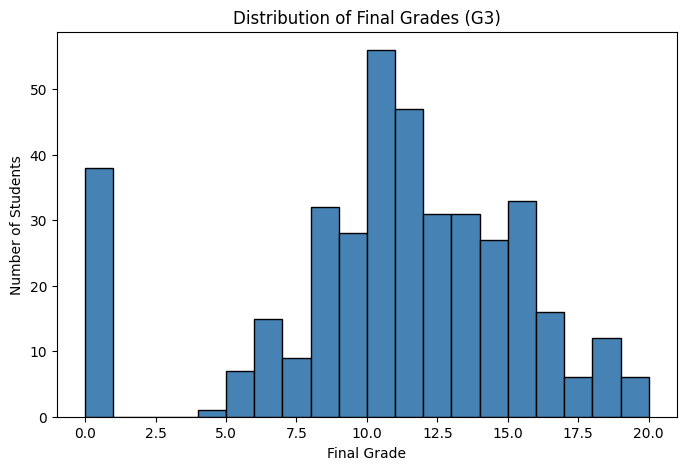

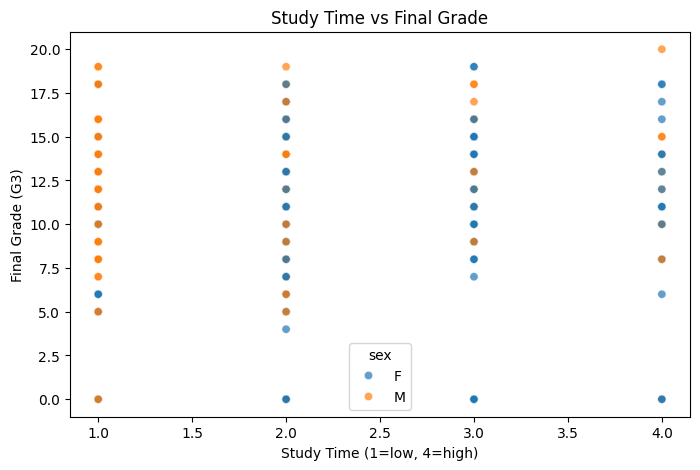

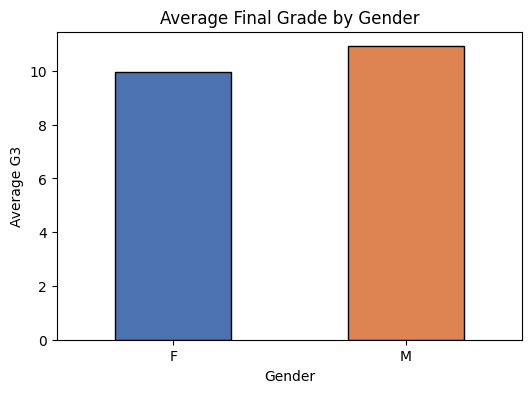

In [36]:
# 1. Histogram of Final Grades
plt.figure(figsize=(8, 5))
plt.hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.show()

# 2. Scatterplot: Study Time vs Grades
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='studytime', y='G3', hue='sex', alpha=0.7)
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=low, 4=high)')
plt.ylabel('Final Grade (G3)')
plt.show()

# 3. Bar Chart: Male vs Female Average Score
plt.figure(figsize=(6, 4))
gender_avg.plot(kind='bar', color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average G3')
plt.xticks(rotation=0)
plt.show()

Additional Visualization

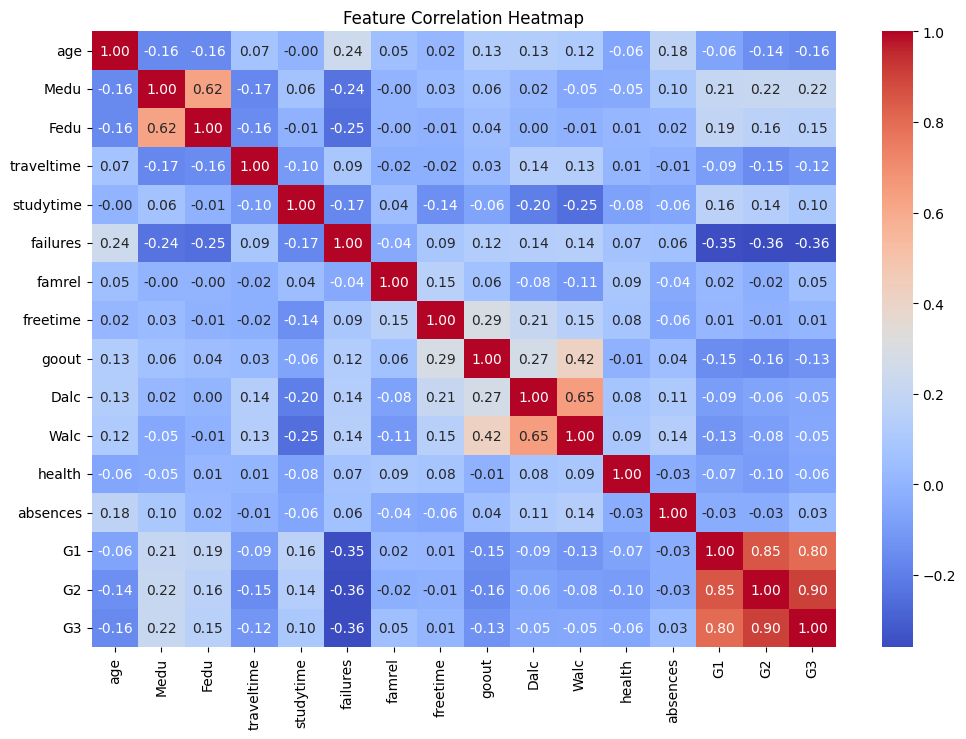

/tmp/ipykernel_3528/992733909.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='failures', y='G3', palette='Set2')


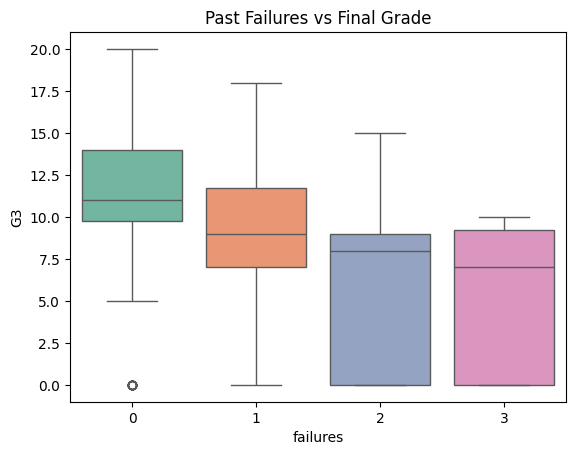

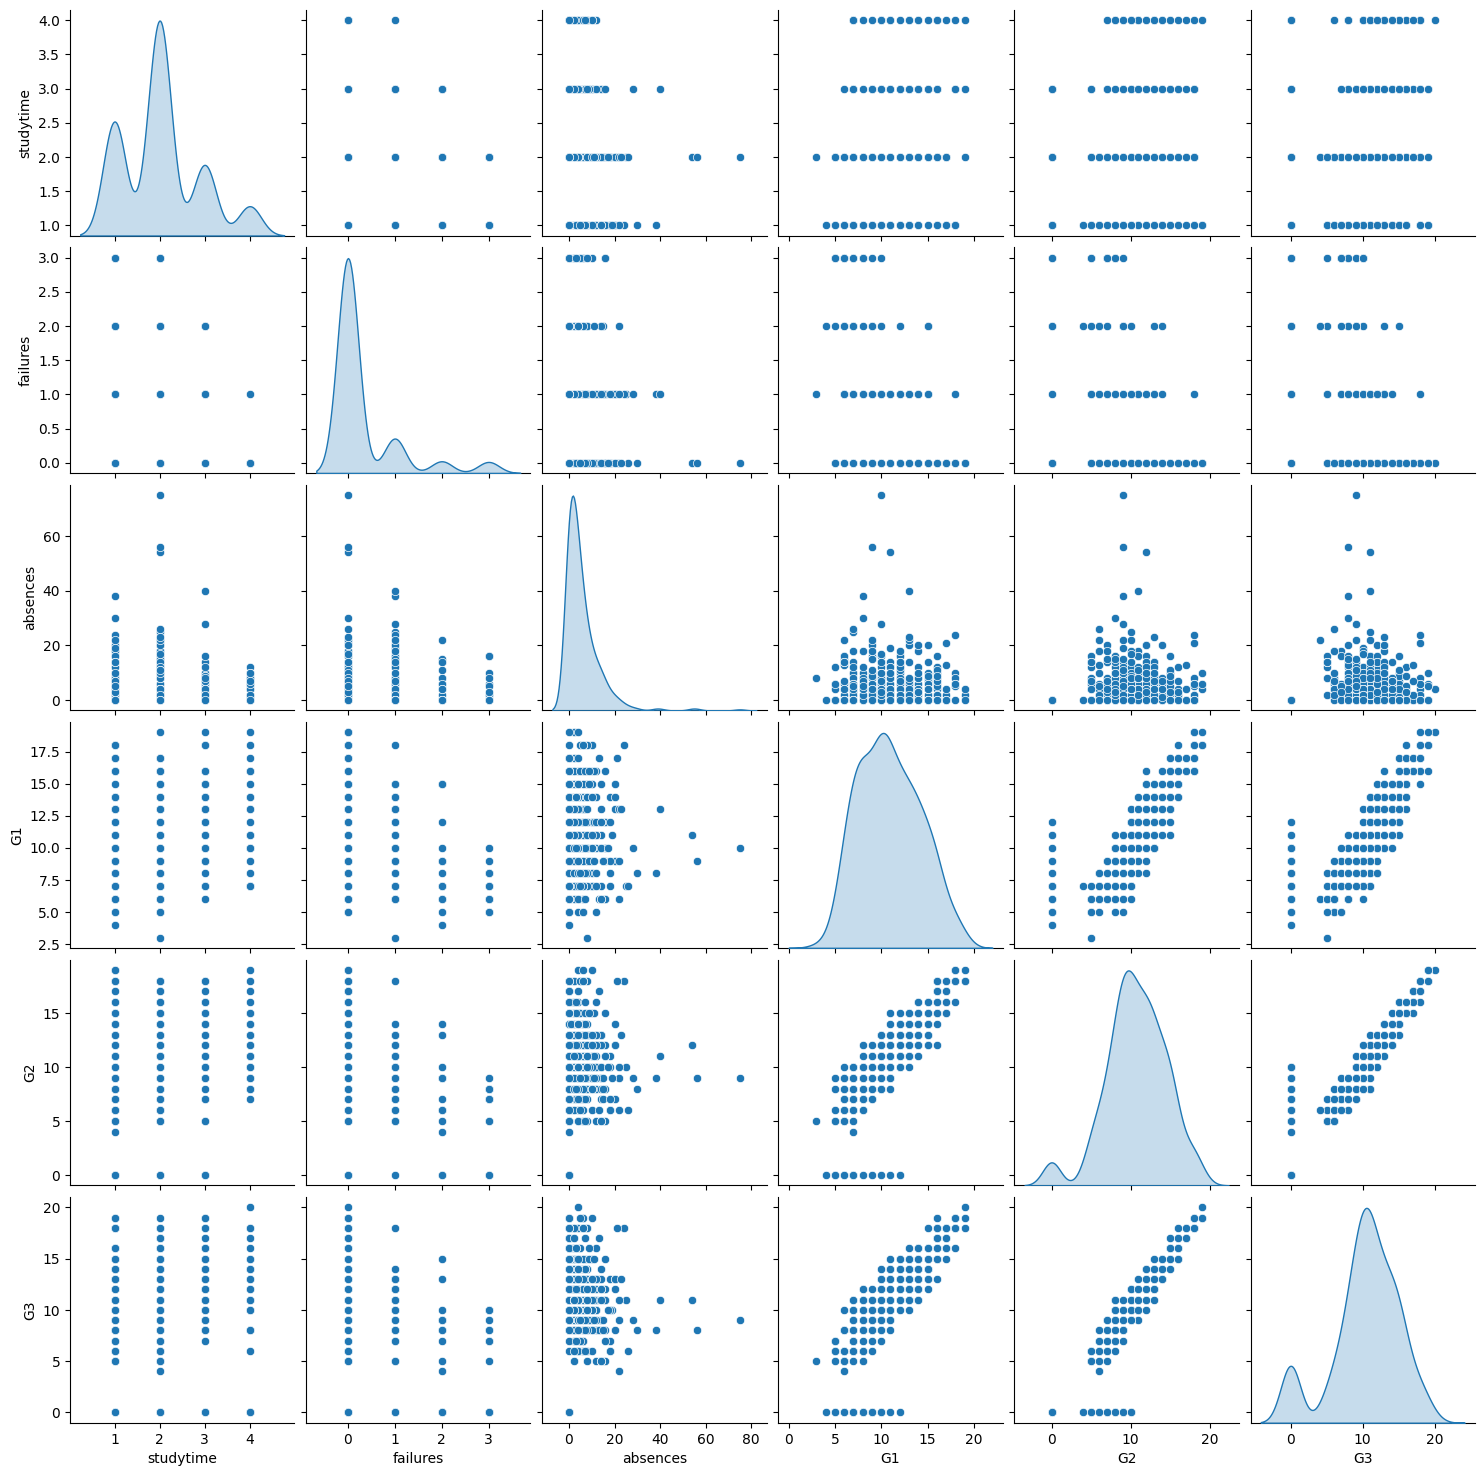

In [37]:
# Heatmap of correlations
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Boxplot: Failures vs Final Grade
sns.boxplot(data=df, x='failures', y='G3', palette='Set2')
plt.title('Past Failures vs Final Grade')
plt.show()

# Pairplot for key features
sns.pairplot(df[['studytime', 'failures', 'absences', 'G1', 'G2', 'G3']], diag_kind='kde')
plt.show()

# Conclusion


- The **average final grade** is approximately **10.42** out of 20.
- **40 students** scored above 15 (high performers).
- There is a **weak positive correlation** between study time and final grade (r = 0.0978),
  meaning students who study more tend to score slightly higher.
- **Male students** perform slightly better on average (**10.91 vs 9.97**).